In [1]:
#load dataset and preprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups #sklearn : 20 newsgroup data : 20 farklı kategoride haber metinleri
from sklearn.preprocessing import LabelEncoder #etiketleri sayısal formata çevirir
from sklearn.model_selection import train_test_split #veriyi eğitim ve test setlerine ayırır

from keras.preprocessing.text import Tokenizer #metin verisini sayılara çevirir
from tensorflow.keras.preprocessing.sequence import pad_sequences #dizileri aynı uzunluğa getirir
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

2025-07-25 16:54:10.728587: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
newsgroup = fetch_20newsgroups(subset="all") #all ile hem eğitim hemde test verileri yüklenir
X = newsgroup.data # X = metinler
y = newsgroup.target # y = metinlere karşılık gelen etiketler

In [3]:
#metin verisini tokenize etme ve padding
tokenizer = Tokenizer(num_words=10000) #num words : en çok kullanılan kelime sayısı
tokenizer.fit_on_texts(X) # tokenizerı metin verisi ile fit edelim 
X_sequences = tokenizer.texts_to_sequences(X) # metinleri sayısala dönüştürür
X_padded = pad_sequences(X_sequences, maxlen = 100) #metinleri aynı uzunluğa getirir

In [4]:
#etiketleri sayısal hala dönüştür (label encoding)
label_encoder =LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [5]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X_padded, y_encoded, test_size=0.2, random_state=42)

In [6]:
#metric tanımlama 
from keras import backend as K 
def f1_score(y_true, y_pred):
    y_pred = K.round(y_pred) #tahminleri 0 veya 1 e yuvarla
    tp = K.sum(K.cast(y_true*y_pred, "float"), axis=0) #true positive
    fp = K.sum(K.cast((1 - y_true)*y_pred, "float"), axis=0) #false positive
    fn = K.sum(K.cast(y_true*(1-y_pred), "float"), axis=0) #false negative
    
    precision = tp / (tp + fp + K.epsilon()) #precision hesaplama
    recall = tp / (tp + fn + K.epsilon()) #recall hesapla
    
    f1 = 2 * (precision * recall)/(precision + recall + K.epsilon())
    
    return K.mean(f1)

In [7]:
#create (build) lstm model
def build_lstm_model():
    model = Sequential()
    
    #katmanlar: embedding + lstm + dropout + output
    #input_dim: kelime vektörlerinin toplam boyutu
    #output_dim: kelime vektörlerinin boyutu
    #input_length: her giriş metninin uzunluğu
    model.add(Embedding(input_dim = 10000, output_dim = 64, input_length = 100))
    
    #lstm katmanı
    #return_sequences: sonuçların tüm zaman adımları yerine sadece son adımda return etmesi
    model.add(LSTM(units = 64, return_sequences = False))
    
    #dropout 
    model.add(Dropout(0.5))
    
    #dense katmanı
    model.add(Dense(20, activation = "softmax"))
    
    #model compile 
    model.compile(optimizer = "adam",
                  loss = "sparse_categorical_crossentropy",
                  metrics = ["accuracy", f1_score])
    
    return model

In [8]:
#model oluşturma 
model = build_lstm_model()
model.summary()

2025-07-25 16:54:20.114233: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 64)           640000    
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 20)                1300      
                                                                 
Total params: 674,324
Trainable params: 674,324
Non-trainable params: 0
_________________________________________________________________


In [9]:
#callbacks = early stop
early_stopping = EarlyStopping(monitor = "val_accuracy", patience = 5, restore_best_weights = True)

In [10]:
#model train
history = model.fit(X_train, y_train,
                    epochs = 5,
                    batch_size = 32,
                    validation_split = 0.1,
                    callbacks = [early_stopping])

Epoch 1/5
424/424 [==============================] - 15s 33ms/step - loss: 2.6727 - accuracy: 0.1633 - f1_score: 0.0014 - val_loss: 2.1484 - val_accuracy: 0.3176 - val_f1_score: 0.0045
Epoch 2/5
424/424 [==============================] - 13s 32ms/step - loss: 1.8625 - accuracy: 0.3727 - f1_score: 0.0168 - val_loss: 1.5792 - val_accuracy: 0.4748 - val_f1_score: 0.0237
Epoch 3/5
424/424 [==============================] - 13s 31ms/step - loss: 1.3452 - accuracy: 0.5486 - f1_score: 0.0427 - val_loss: 1.3287 - val_accuracy: 0.5590 - val_f1_score: 0.0505
Epoch 4/5
424/424 [==============================] - 13s 32ms/step - loss: 1.0578 - accuracy: 0.6510 - f1_score: 0.0600 - val_loss: 1.1765 - val_accuracy: 0.6247 - val_f1_score: 0.0588
Epoch 5/5
424/424 [==============================] - 13s 32ms/step - loss: 0.8289 - accuracy: 0.7281 - f1_score: 0.0715 - val_loss: 1.1191 - val_accuracy: 0.6439 - val_f1_score: 0.0702


In [11]:
#test veri seti ile değerlendirme
loss, accuracy, f1_score = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss: 4f}, Test Accuracy: {accuracy: 4f}, f1_score: {f1_score: 4f}")

118/118 [==============================] - 2s 13ms/step - loss: 1.1433 - accuracy: 0.6374 - f1_score: 0.0700
Test Loss:  1.143332, Test Accuracy:  0.637401, f1_score:  0.070008


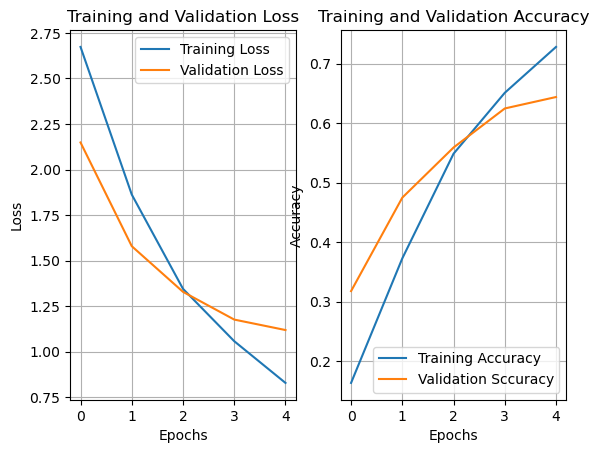

In [12]:
#history kullanarak accuracy ve loss değerlerini görselleştirme
plt.figure()

#training loss ve val loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid("True")

#training accuracy and val accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Sccuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid("True")